[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch04_workbook.ipynb)

# Word vectors from co-occurrence

A word's vector counts the words that stand near it in Pride and Prejudice.
Two words that keep the same company get vectors that point the same way,
and the cosine between the two vectors measures how closely they do.

In [1]:
#@title Setup: run this cell first
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


MIN_COUNT = 5  # a word seen fewer times in the novel gets no vector
# Five kinds of word, named by hand, for the map and the exercise.
KINDS = {"relatives": "mother father sister brother aunt uncle", "feelings": "happy angry pleased glad sorry afraid",
         "places": "london meryton netherfield pemberley longbourn brighton",
         "movement": "walked ran went came returned entered", "speech": "said replied cried answered added continued"}


def whole(x, name, top, low=1):
    # True for a whole number from low to top; otherwise a sentence saying so, and None.
    if isinstance(x, (int, np.integer)) and low <= x <= top:
        return True
    print(f"{name} is a whole number from {low} to {top:,}, and {x!r} is not one.")


def lookup(word):
    # The row of a typed word, or None after a sentence saying why it has none.
    w = re.findall(r"[^\W\d_]+(?:'[^\W\d_]+)*", str(word).lower().replace("’", "'"))
    if len(w) == 1 and w[0] in index:
        return index[w[0]]
    print(f'"{w[0]}" has a count of {freq[w[0]]}; a vector needs {MIN_COUNT}.' if len(w) == 1 else f"{word!r} is not one word.")


def positive_pmi(M):
    # max(PMI(i, j), 0) for every cell of a co-occurrence matrix, and 0 where the pair never co-occurs.
    total, row = M.sum(), M.sum(axis=1, keepdims=True)
    return np.maximum(np.log(np.where(M > 0, M * total / (row * row.T), 1)), 0)


def vectors(window, weight="raw counts"):
    # Each word's row: how often every word stands within `window` words of it, either side,
    # as a raw count or as positive PMI; None for a window outside 1 to 50.
    if whole(window, "WINDOW", 50):
        a, b = np.concatenate([[ids[:-d], ids[d:]] for d in range(1, window + 1)], axis=1)  # every pair d apart
        keep, n = (a >= 0) & (b >= 0), len(vocab)
        m = np.bincount(a[keep] * n + b[keep], minlength=n * n).reshape(n, n)
        return m + m.T if weight == "raw counts" else positive_pmi(m + m.T)


def nearest(word, window=2, weight="raw counts", X=None, k=5):
    # The k words whose rows point closest to the word's row, with their cosines, and the median
    # cosine of all words to it; None when the word or the window has no rows.
    i, X = lookup(word), vectors(window, weight) if X is None else X
    if i is not None and X is not None:
        c = X @ X[i] / np.maximum(np.linalg.norm(X, axis=1), 1e-12) / np.linalg.norm(X[i])
        return [(vocab[j], c[j]) for j in np.argsort(-c) if j != i][:k], np.median(c)


def show_nearest(word, *windows, weight="raw counts"):
    # One panel of bars per window: the five nearest words, each labelled with its cosine.
    got = [nearest(word, w, weight) for w in windows] if lookup(word) is not None else [None]
    if all(got):
        fig, axes = plt.subplots(1, len(windows), figsize=(6, 3.5), squeeze=False, layout="constrained")
        for ax, w, (rows, _) in zip(axes[0], windows, got):
            ax.bar_label(ax.barh(range(len(rows)), [c for _, c in rows], tick_label=[v for v, _ in rows]), fmt="%.2f", padding=2)
            ax.set(xlim=(0, 1.2 * max(c for r, _ in got for _, c in r)), ylim=(len(rows) - 0.5, -0.5), title=f"window {w}")
        fig.supxlabel(f'cosine similarity to "{vocab[lookup(word)]}", rows of {weight}')
        plt.show()


def shared(pair, draw=False, window=2):
    # The two words, the cosine of their rows, and the context words both rows count, by the smaller share.
    words = pair.split() if isinstance(pair, str) else pair if isinstance(pair, (tuple, list)) else ()
    rows = [lookup(w) for w in words] if len(words) == 2 else print(f"PAIR takes two words, and {pair!r} is not two.")
    if rows is not None and None not in rows:  # otherwise a sentence above says why, and the result is None
        (a, b), (sa, sb) = rows, [100 * m / m.sum() for m in vectors(window)[rows]]
        both = sorted(np.flatnonzero((sa > 0) & (sb > 0)), key=lambda j: -min(sa[j], sb[j]))
        cos, top = sa @ sb / np.linalg.norm(sa) / np.linalg.norm(sb), [(vocab[j], sa[j], sb[j]) for j in both]
        if draw and not top:
            print(f'"{vocab[a]}" and "{vocab[b]}" share no context word within {window} words, so their cosine is 0.')
        elif draw:
            y, rows = np.arange(len(top[:8])), top[:8]
            fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
            ax.barh(y - 0.2, [r[1] for r in rows], 0.4, label=f'"{vocab[a]}"')
            ax.barh(y + 0.2, [r[2] for r in rows], 0.4, label=f'"{vocab[b]}"', fill=False, hatch="///", ec="C1")
            ax.set(yticks=y, yticklabels=[r[0] for r in rows], ylim=(len(rows) - 0.5, -0.5),
                   xlabel="share of the word's neighbours (%)", title=f"cosine similarity {cos:.2f}, window {window}")
            fig.legend(ncols=2, loc="outside upper right")
            plt.show()
        return vocab[a], vocab[b], cos, top


def embed(weight, k):
    # The rows of U_k Σ_k of the window-2 rows under a weighting; None for a bad k.
    if whole(k, "K", len(vocab), low=2):
        return svds[weight][0][:, :k] * svds[weight][1][:k]


def kind_share(E):
    # For each kind, the share of its words' five nearest words that are of the same kind.
    return {kind: np.mean([v in group for w in group for v, _ in nearest(w, X=E)[0]]) for kind, group in KINDS.items()}


tokens = [w for chapter in load_novel() for w in chapter]
freq = Counter(tokens)
vocab = [w for w, c in freq.most_common() if c >= MIN_COUNT]
index = {w: i for i, w in enumerate(vocab)}
ids = np.array([index.get(w, -1) for w in tokens])
svds = {w: np.linalg.svd(vectors(2, w), hermitian=True)[:2] for w in ("raw counts", "positive PMI")}
KINDS = {kind: [w for w in group.split() if w in index] for kind, group in KINDS.items()}
print(f"{len(tokens):,} tokens, {len(freq):,} word types; {len(vocab):,} words seen {MIN_COUNT} times or more get vectors.")

122,174 tokens, 6,314 word types; 2,077 words seen 5 times or more get vectors.


## 1. Nearest words by co-occurrence

Each word seen five times or more has a row that counts the words within two
places of it, either side. Run the cell to draw the five words whose rows
point closest to the row of "elizabeth". Which word is nearest, and how close
is it? Then put a word of your own into `WORD` and run the cell again.

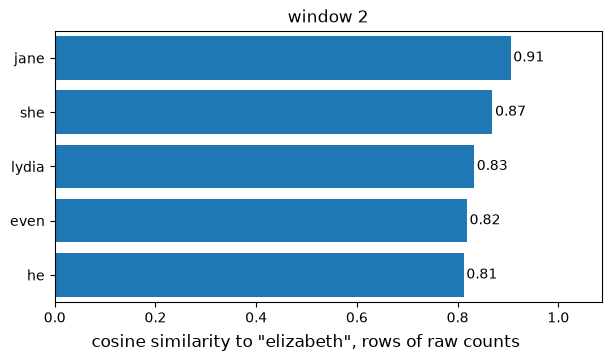

In [2]:
WORD = "elizabeth"
show_nearest(WORD, 2)

### Solution

In [3]:
got = nearest(WORD)
if got:
    display(Markdown(f"The five nearest to \"{vocab[lookup(WORD)]}\" are " + ", ".join(f"\"{v}\" ({x:.2f})" for v, x in got[0])
                     + f". The median word of the {len(vocab):,} scores {got[1]:.2f} against it."))

The five nearest to "elizabeth" are "jane" (0.91), "she" (0.87), "lydia" (0.83), "even" (0.82), "he" (0.81). The median word of the 2,077 scores 0.44 against it.

## 2. Shared context words make two words similar

Run the cell to draw the context words that both "sister" and "brother" count
most, each as a share of the word's neighbours, under the cosine of their
rows. How similar are the two words, and which context words do they share
most?

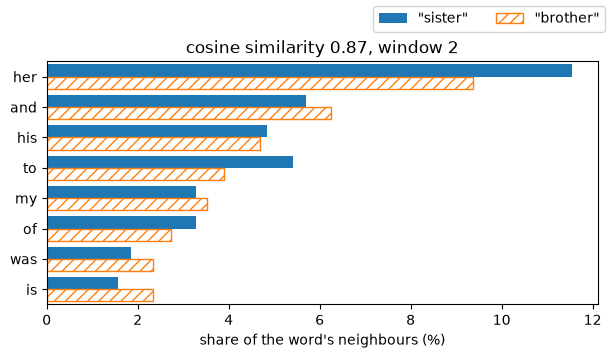

In [4]:
PAIR = ("sister", "brother")
got = shared(PAIR, draw=True)

### Solution

In [5]:
got = shared(PAIR)
if got:
    display(Markdown(f"\"{got[0]}\" and \"{got[1]}\" have cosine {got[2]:.2f} and share {len(got[3]):,} context words. "
                     + "".join(f"\"{w}\" takes {x:.1f} and {y:.1f} per cent of their neighbours. " for w, x, y in got[3][:3])))

"sister" and "brother" have cosine 0.87 and share 65 context words. "her" takes 11.5 and 9.4 per cent of their neighbours. "and" takes 5.7 and 6.2 per cent of their neighbours. "his" takes 4.8 and 4.7 per cent of their neighbours. 

## 3. The window sets which words count as company

Here each row holds positive PMI, which scores a pair by how much more often
it co-occurs than chance and so discounts pairs that are common only because
one word is frequent. The word is "ball", chosen because its two lists differ
cleanly; for many words the list at the wider window still holds some of the
commonest words. Run the cell to draw the five nearest words to "ball" with a
window of 2 words either side, beside a window of 10. Which of the two lists
stands within `WINDOW` words of "ball" in the novel more often? Then set
`WINDOW` to a width of your own.

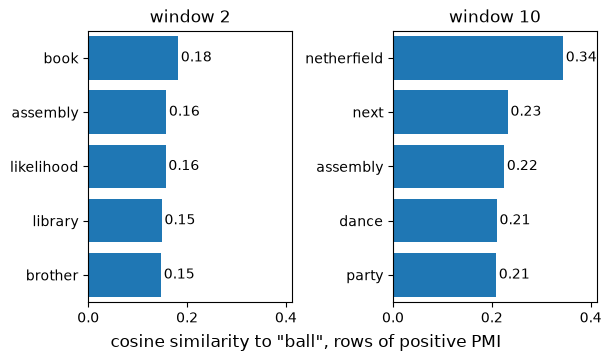

In [6]:
WINDOW = 2
show_nearest("ball", WINDOW, 10, weight="positive PMI")

### Solution

In [7]:
got = [nearest("ball", w, "positive PMI") for w in (WINDOW, 10)]
if all(got):
    (near, wide), row = [[w for w, _ in rows] for rows, _ in got], vectors(WINDOW)[index["ball"]]
    n1, n2 = [sum(row[index[w]] for w in five) for five in (near, wide)]
    display(Markdown(f"Window {WINDOW}: {', '.join(near)}. Window 10: {', '.join(wide)}. Within {WINDOW} words of "
                     f"\"ball\", the novel holds the first five {n1:,.0f} times and the second five {n2:,.0f} times."))

Window 2: book, assembly, likelihood, library, brother. Window 10: netherfield, next, assembly, dance, party. Within 2 words of "ball", the novel holds the first five 0 times and the second five 10 times.

## Appendix. Positive PMI and truncated SVD

A raw count is large wherever either word is frequent, so the commonest words
of the novel take a large share of most rows. Pointwise mutual information
compares the count M[i, j] of a pair with the count chance would give it:

PMI(i, j) = log( P(i, j) / (P(i) · P(j)) ),

where P(i, j) = M[i, j] / Σ M, and P(i) is row i's sum over Σ M. Positive PMI
keeps max(PMI(i, j), 0), and a pair that never co-occurs gets 0. Truncated SVD
factorises the positive-PMI matrix X ≈ U_k Σ_k V_kᵀ and keeps the top k
components; a word's embedding is its row of U_k Σ_k. With all components
kept, the cosines of the embeddings equal the cosines of the rows of X.

The map takes thirty words of five kinds, embedded at a window of 2 with
k = 50, and projects them onto the two directions along which those thirty
words vary most. The kinds are named by hand and play no part in the
positions.

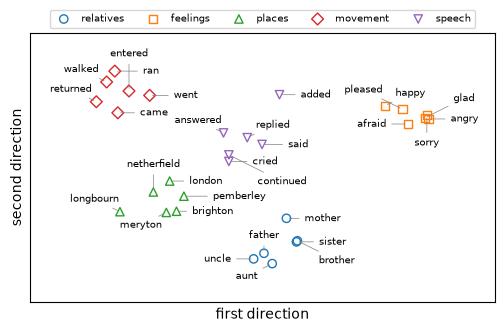

In [8]:
E, words = embed("positive PMI", 50), sum(KINDS.values(), [])
X = np.array([E[index[w]] / np.linalg.norm(E[index[w]]) for w in words])
u, s, _ = np.linalg.svd(X - X.mean(axis=0), full_matrices=False)
xy, (fig, ax) = u[:, :2] * s[:2], plt.subplots(figsize=(6, 3.5))
for i, (kind, group) in enumerate(KINDS.items()):  # hollow markers, so two at one point both show
    ax.scatter(*xy[[words.index(w) for w in group]].T, marker="os^Dv"[i], fc="none", ec=f"C{i}", label=kind)
ax.set(xlabel="first direction", ylabel="second direction", xticks=[], yticks=[], xmargin=0.2, ymargin=0.2)
ax.legend(ncols=5, loc="lower center", bbox_to_anchor=(0.5, 1), fontsize=7)
fig.canvas.draw()  # fixes the axes, so each point has its place on the page, in points
# Each label takes the first of 24 spots around its point whose box, 5.2 points a letter and 10 high,
# meets no marker and no label placed before it; a grey line joins it to its point.
dots = ax.transData.transform(xy) * 72 / fig.dpi
taken = [(x - 4, y - 4, x + 4, y + 4) for x, y in dots]
for w, (x, y), p in zip(words, dots, xy):
    spots = [(r * np.cos(t), r * np.sin(t) / 2) for r in (26, 40, 54) for t in np.arange(8) * np.pi / 4]
    boxes = [((dx, dy), (x + dx - 2.6 * len(w), y + dy - 5, x + dx + 2.6 * len(w), y + dy + 5)) for dx, dy in spots]
    spot, box = next(((s, b) for s, b in boxes if not any(
        b[0] < t[2] and t[0] < b[2] and b[1] < t[3] and t[1] < b[3] for t in taken)), boxes[0])
    taken.append(box)
    ax.annotate(w, p, spot, textcoords="offset points", fontsize=7, ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
plt.show()

**Exercise.** A word scores the share of its five nearest words that are of
its own kind on the map, and a weighting scores the mean over the thirty
words. Set `K` to 30, 40, 50, 60 and 100 in turn and rerun the cell; k starts
at 2, since with one component every cosine is 1 or −1. How far does each
weighting's score move from one k to the next, and does positive PMI score
above raw counts at every k you tried?

In [9]:
K = 30

if whole(K, "K", len(vocab), low=2):
    for weight in ("positive PMI", "raw counts"):
        print(f"{weight}, k = {K}: {np.mean(list(kind_share(embed(weight, K)).values())):.0%} of the five nearest are of the same kind")

positive PMI, k = 30: 33% of the five nearest are of the same kind
raw counts, k = 30: 31% of the five nearest are of the same kind


### Solution

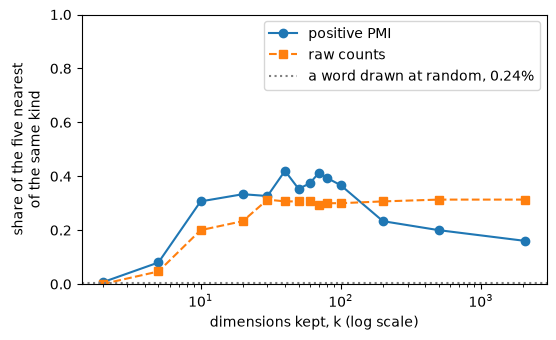

Over the values of k drawn from 30 to 100, one step moves the score by up to 9 points for positive PMI and 1 for raw counts, so the highest marks no single best k; positive PMI minus raw counts runs from +1 to +12 points. All 2,077 dimensions give 16% and 31%, a random word 0.24%. At k = 50, by kind, positive PMI against raw counts: relatives 57% and 53%, feelings 20% and 10%, places 53% and 27%, movement 17% and 17%, speech 30% and 47%.

In [10]:
ks = [2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 100, 200, 500, len(vocab)]
by_kind = {weight: [kind_share(embed(weight, k)) for k in ks] for weight in ("positive PMI", "raw counts")}
p, r = [[np.mean(list(d.values())) for d in ds] for ds in by_kind.values()]
fig, ax = plt.subplots(figsize=(6, 3.5))
for ys, weight, style in zip((p, r), by_kind, ("o-", "s--")):
    ax.plot(ks, ys, style, label=weight)
ax.axhline(5 / (len(vocab) - 1), color="grey", ls=":", label=f"a word drawn at random, {5 / (len(vocab) - 1):.2%}")
ax.set(xscale="log", xlabel="dimensions kept, k (log scale)", ylabel="share of the five nearest\nof the same kind", ylim=(0, 1))
ax.legend()
plt.show()
mid, at50 = slice(ks.index(30), ks.index(100) + 1), ks.index(50)
step, lead = [100 * np.abs(np.diff(ys[mid])).max() for ys in (p, r)], 100 * (np.array(p) - r)[mid]
kinds = ", ".join(f"{k} {by_kind['positive PMI'][at50][k]:.0%} and {by_kind['raw counts'][at50][k]:.0%}" for k in KINDS)
display(Markdown(f"Over the values of k drawn from 30 to 100, one step moves the score by up to {step[0]:.0f} points for "
                 f"positive PMI and {step[1]:.0f} for raw counts, so the highest marks no single best k; positive PMI minus "
                 f"raw counts runs from {lead.min():+.0f} to {lead.max():+.0f} points. All {len(vocab):,} dimensions give {p[-1]:.0%} "
                 f"and {r[-1]:.0%}, a random word {5 / (len(vocab) - 1):.2%}. At k = 50, by kind, positive PMI against raw counts: {kinds}."))